# Solutions: Communities & Substructures
*This notebook contains the solutions to the exercises presented at the end of Notebook 3.*


### Environment Setup
Run this cell to import the necessary libraries and load the dataset used in the exercises.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import networkx.algorithms.community as nx_comm

# Configure visual styling
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("Environment setup complete.")


Environment setup complete.


---
### Solution 1: Exploring Les Misérables
**Goal:** Load the dataset and find the total number of connected components and average clustering coefficient.


In [2]:
# 1. Load the graph
LM = nx.les_miserables_graph()

print(f"Nodes: {LM.number_of_nodes()}")
print(f"Edges: {LM.number_of_edges()}")

# 2. Total number of connected components
num_components = nx.number_connected_components(LM)
print(f"\nTotal connected components: {num_components}")
print("(This means everyone in this network is connected by some path!)")

# 3. Average Clustering Coefficient
avg_clustering = nx.average_clustering(LM)
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")


Nodes: 77
Edges: 254

Total connected components: 1
(This means everyone in this network is connected by some path!)
Average Clustering Coefficient: 0.5731


---
### Solution 2: Louvain Partitioning on Les Misérables
**Goal:** Run the Louvain algorithm, count the communities, and calculate the Modularity score.


In [3]:
# 1. Run the Louvain algorithm
louvain_communities = nx_comm.louvain_communities(LM, seed=42)

# 2. Distinct communities found
num_communities = len(louvain_communities)
print(f"Total distinct communities found: {num_communities}")

# Print a quick summary of sizes
sizes = [len(c) for c in louvain_communities]
print(f"Community sizes: {sizes}\n")

# 3. Modularity Score
mod_louvain = nx_comm.modularity(LM, louvain_communities)
print(f"Modularity Score: {mod_louvain:.4f}")
print("Conclusion: Yes! A score of ~0.57 is considered a very strong community structure, indicating the characters form tight-knit, distinct sub-groups in the novel.")


Total distinct communities found: 6
Community sizes: [10, 9, 6, 10, 25, 17]

Modularity Score: 0.5654
Conclusion: Yes! A score of ~0.57 is considered a very strong community structure, indicating the characters form tight-knit, distinct sub-groups in the novel.


---
### Solution 3: Visualizing the Factions
**Goal:** Plot the graph and color each node by its Louvain community assignment.


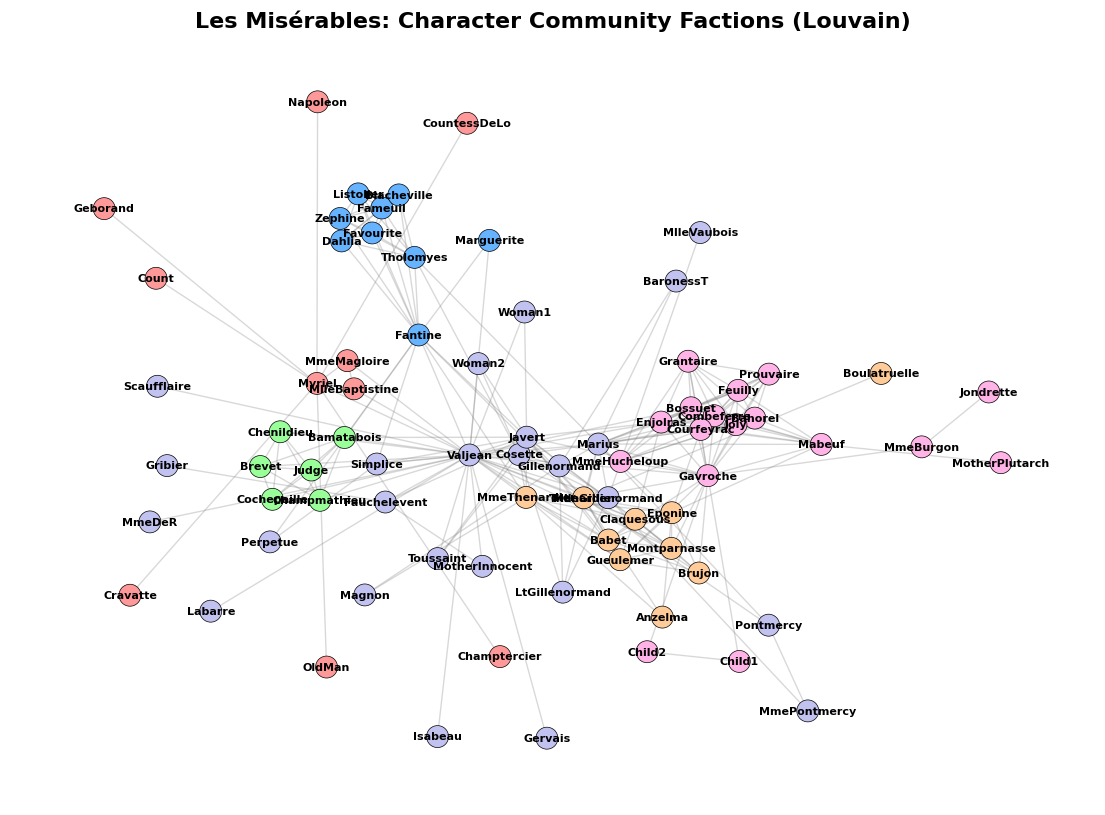

In [4]:
# Create an extended color map since we have 6+ communities here
community_color_map = {}
colors = [
    "#ff9999", "#66b3ff", "#99ff99", "#ffcc99", "#c2c2f0", 
    "#ffb3e6", "#c4e17f", "#ffff99", "#fccde5"
]

# Assign a specific color to each node based on its community
for idx, comm in enumerate(louvain_communities):
    for node in comm:
        community_color_map[node] = colors[idx % len(colors)]

# Make sure the colors list matches the exact order of LM.nodes()
node_colors = [community_color_map[node] for node in LM.nodes()]

# Setup layout
plt.figure(figsize=(14, 10))

# We use k=0.5 to push the nodes a bit further apart to avoid label overlapping
pos = nx.spring_layout(LM, seed=42, k=0.5)

# Draw the network
nx.draw_networkx_nodes(LM, pos, node_color=node_colors, node_size=250, edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(LM, pos, alpha=0.3, edge_color="gray")

# Draw the labels with a smaller font
nx.draw_networkx_labels(LM, pos, font_size=8, font_weight="bold")

plt.title("Les Misérables: Character Community Factions (Louvain)", fontsize=16, fontweight="bold")
plt.axis("off")
plt.show()
